In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer, RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('AmesHousing.csv')
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.tail()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [5]:
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
264,265,907252120,20,RL,NaN,11423,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,2000,5,2010,WD,Normal,272000
476,477,528235200,80,RL,59.0,9434,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,170000
461,462,528186180,120,RL,48.0,6240,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,12,2009,WD,Normal,254000
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000
1504,1505,908225170,190,RL,56.0,6931,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,91900


In [6]:
df.shape

(2930, 82)

In [7]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [9]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [10]:
df.describe(include='object')

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [11]:
df.isnull().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

## Univariate Analysis of `SalePrice`

`SalePrice` is the **target variable** of the Ames Housing dataset. It represents the final selling price of each residential property. Since the objective of this project is to predict house prices, understanding the distribution and statistical characteristics of `SalePrice` is particularly important.

### Descriptive Statistics

| Statistic | Sale Price |
|---|---:|
| Count | 2,930 |
| Mean | 180,796.06 |
| Standard Deviation | 79,886.69 |
| Minimum | 12,789 |
| 25th Percentile (Q1) | 129,500 |
| Median (Q2) | 160,000 |
| 75th Percentile (Q3) | 213,500 |
| Maximum | 755,000 |

### Distribution Analysis

The histogram and KDE plot show that the `SalePrice` distribution is **positively (right) skewed**.

- Most houses are concentrated roughly in the lower-to-middle price range.
- The highest density of observations appears around the $100,000–$200,000 range.
- The distribution has a long right tail caused by a relatively small number of expensive properties.
- The mean sale price ($180,796) is greater than the median ($160,000), which further indicates positive skewness.
- The distribution is therefore not symmetric or normally distributed.

### Central Tendency

The mean house price is approximately **$180,796**, while the median is **$160,000**.

Since:

**Mean > Median**

the higher-priced properties are pulling the mean upward. For this skewed distribution, the median provides a better representation of the price of a typical property than the mean.

### Spread of Sale Prices

The standard deviation is approximately **$79,887**, indicating substantial variation in property prices.

The middle 50% of houses lie between:

- Q1 = $129,500
- Q3 = $213,500

Therefore, the Interquartile Range (IQR) is:

**IQR = Q3 - Q1**

**IQR = 213,500 - 129,500 = $84,000**

This means that the middle 50% of properties have sale prices spread across an $84,000 range.

### Outlier Analysis

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 129,500 - 1.5(84,000) = $3,500**

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 213,500 + 1.5(84,000) = $339,500**

Therefore, observations with `SalePrice` greater than approximately **$339,500** are identified as potential upper outliers according to the IQR rule.

The box plot confirms the presence of numerous high-price observations above the upper whisker, including a few extremely expensive properties approaching $755,000.

However, these observations should **not be removed automatically**. Expensive houses can represent legitimate properties rather than incorrect data. Their relationship with other features such as living area, overall quality, neighborhood, and garage size should be investigated before deciding how to handle them.

### Range

The cheapest property was sold for **$12,789**, while the most expensive property was sold for **$755,000**.

This gives a total range of:

**$755,000 - $12,789 = $742,211**

The very large range demonstrates substantial variation in house prices within the dataset.

### Key Observations

1. `SalePrice` contains 2,930 observations.
2. The median sale price is $160,000.
3. The mean sale price is approximately $180,796.
4. The distribution is positively/right skewed.
5. Most properties are concentrated in the lower-to-middle price ranges.
6. A long right tail is created by expensive properties.
7. The box plot shows numerous potential upper outliers.
8. The middle 50% of properties are priced between $129,500 and $213,500.
9. The IQR is $84,000.
10. The maximum sale price ($755,000) is substantially higher than the 75th percentile ($213,500).
11. Potential outliers should be investigated rather than immediately removed.
12. Because this is the regression target, a transformation such as `log1p(SalePrice)` may later be investigated to reduce right skewness.

### Conclusion

`SalePrice` is a continuous numerical variable with a clearly **right-skewed distribution and several high-value observations**. The large difference between the maximum value and the upper quartile indicates that a relatively small number of expensive houses form a long upper tail.

Before model training, the skewness and extreme values should be investigated further. A logarithmic transformation may be useful for making the target distribution more symmetric, but this decision should be based on additional analysis rather than applied automatically.

In [13]:
df['SalePrice']

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2930, dtype: int64

In [14]:
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

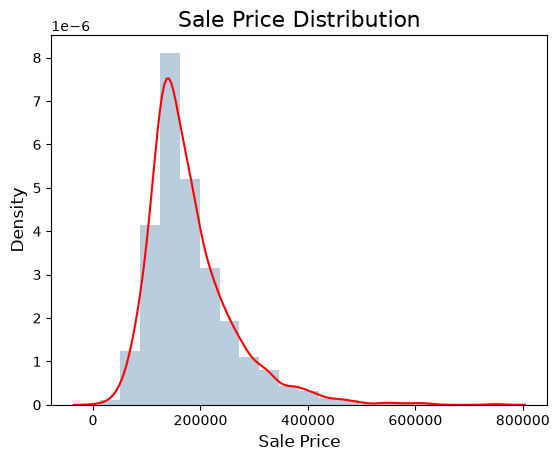

In [15]:
sns.distplot(
    df['SalePrice'],
    bins=20,
    color='#5484ac',
    kde_kws={'color' : 'red'}
)
plt.title("Sale Price Distribution", fontsize=16)
plt.xlabel("Sale Price", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

In [16]:
df['SalePrice'].skew()

np.float64(1.7435000757376466)

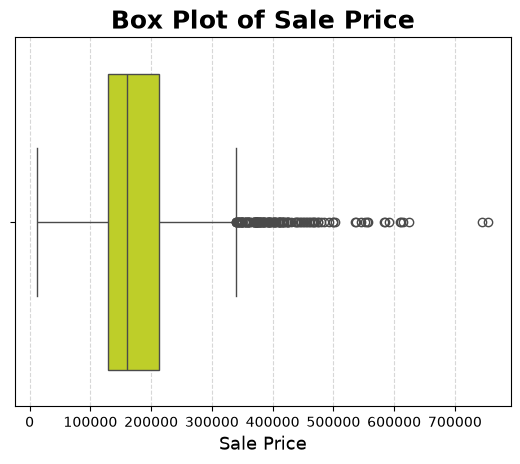

In [17]:
sns.boxplot(data=df, x='SalePrice', color="#D4EA0D")
plt.title("Box Plot of Sale Price", fontsize=18, fontweight="bold")
plt.xlabel("Sale Price", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [18]:
df[df['SalePrice'] > 350000]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
15,16,527216070,60,RL,47.0,53504,Pave,NaN,IR2,HLS,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
17,18,527258010,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
36,37,528108120,60,RL,102.0,12858,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2010,New,Partial,376162
38,39,528120060,20,RL,83.0,10159,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,New,Partial,395192
44,45,528150070,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,2667,902400110,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
2737,2738,905427030,75,RL,60.0,19800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,415000
2883,2884,911370430,120,RM,41.0,5748,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,2,2006,New,Partial,375000
2901,2902,921205030,20,RL,88.0,11443,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2006,New,Partial,369900


In [19]:
print(df['SalePrice'].isnull().sum())

0


## Univariate Analysis of `Lot Frontage`

`Lot Frontage` is a **numerical continuous variable** that represents the linear feet of street connected to a property. In simple terms, it measures how wide the property is along the street.

### Descriptive Statistics

| Statistic | Lot Frontage |
|---|---:|
| Total Dataset Rows | 2,930 |
| Non-Missing Count | 2,440 |
| Missing Count | 490 |
| Missing Percentage | 16.72% |
| Mean | 69.22 |
| Standard Deviation | 23.37 |
| Minimum | 21 |
| 25th Percentile (Q1) | 58 |
| Median (Q2) | 68 |
| 75th Percentile (Q3) | 80 |
| Maximum | 313 |

### Missing Values Analysis

`Lot Frontage` contains **490 missing values out of 2,930 observations**, which corresponds to approximately **16.72% of the dataset**.

This is a significant amount of missing data and should not simply be ignored.

The missing values will need to be investigated during the preprocessing stage. Possible strategies may include median imputation or more context-aware imputation using related property characteristics such as `Neighborhood` or `Lot Area`.

No imputation should be performed yet during univariate EDA.

### Distribution Analysis

The histogram and KDE plot show that `Lot Frontage` has a **positively (right) skewed distribution**.

Most properties have lot frontage values concentrated approximately between **50 and 100 feet**, with the highest concentration around 60–80 feet.

The distribution also contains a long right tail extending beyond 150 feet, with an extreme observation around 313 feet.

The mean (`69.22`) is slightly greater than the median (`68`), which is consistent with the presence of right skewness.

### Central Tendency

The average lot frontage is approximately **69.22 feet**, while the median is **68 feet**.

Since the mean and median are relatively close, the center of the main distribution is reasonably stable. However, several large frontage values pull the distribution toward the right.

### Spread

The standard deviation is approximately **23.37 feet**, indicating noticeable variation in property frontage.

The middle 50% of observations lie between:

- Q1 = 58 feet
- Q3 = 80 feet

Therefore:

**IQR = Q3 - Q1**

**IQR = 80 - 58 = 22 feet**

Thus, the middle 50% of properties have lot frontage values within a 22-foot range.

### Outlier Analysis

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 58 - 1.5(22) = 25 feet**

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 80 + 1.5(22) = 113 feet**

Therefore:

- Values below approximately **25 feet** are potential lower outliers.
- Values above approximately **113 feet** are potential upper outliers.

The box plot confirms the presence of several upper outliers, particularly between approximately 115 and 200 feet, as well as an extreme value of **313 feet**.

There also appear to be a small number of potential lower outliers near the minimum value of 21 feet.

These observations should **not be removed automatically** because unusually wide or narrow properties may be legitimate houses.

### Range

The minimum lot frontage is **21 feet**, while the maximum is **313 feet**.

Therefore:

**Range = 313 - 21 = 292 feet**

The large range is primarily influenced by a relatively small number of properties with unusually large street frontage.

### Key Observations

1. `Lot Frontage` is a continuous numerical variable.
2. There are 2,440 non-missing observations.
3. 490 values are missing, representing approximately 16.72% of the dataset.
4. The median lot frontage is 68 feet.
5. The mean lot frontage is approximately 69.22 feet.
6. Most observations are concentrated roughly between 50 and 100 feet.
7. The distribution is positively/right skewed.
8. The IQR is 22 feet.
9. Values below 25 feet and above 113 feet are potential outliers according to the IQR rule.
10. Several upper outliers are visible in the box plot.
11. The maximum value of 313 feet is particularly extreme compared with the rest of the distribution.
12. Missing values and outliers should be investigated during preprocessing rather than immediately removed.

### Conclusion

`Lot Frontage` has a **slightly right-skewed distribution with several extreme values and a substantial amount of missing data**. Approximately **16.72% of its observations are missing**, making missing-value treatment an important preprocessing decision.

The presence of outliers does not necessarily indicate incorrect data because some properties can legitimately have unusually large street frontage. Therefore, both missing values and extreme observations should be investigated further before choosing an imputation, transformation, or outlier-handling strategy.

In [20]:
df['Lot Frontage']

0       141.0
1        80.0
2        81.0
3        93.0
4        74.0
        ...  
2925     37.0
2926      NaN
2927     62.0
2928     77.0
2929     74.0
Name: Lot Frontage, Length: 2930, dtype: float64

In [21]:
df['Lot Frontage'].describe()

count    2440.000000
mean       69.224590
std        23.365335
min        21.000000
25%        58.000000
50%        68.000000
75%        80.000000
max       313.000000
Name: Lot Frontage, dtype: float64

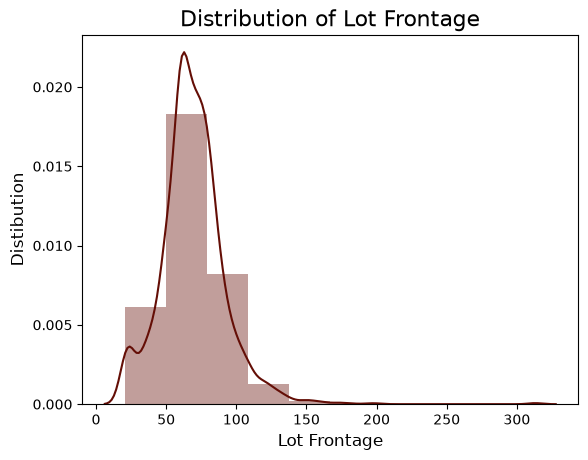

In [22]:
sns.distplot(
    df['Lot Frontage'],
    bins=10,
    color="#640e06"
)
plt.title("Distribution of Lot Frontage", fontsize=16)
plt.xlabel("Lot Frontage", fontsize=12)
plt.ylabel("Distibution", fontsize=12)
plt.show()

In [23]:
print(df['Lot Frontage'].skew())

1.499067354883421


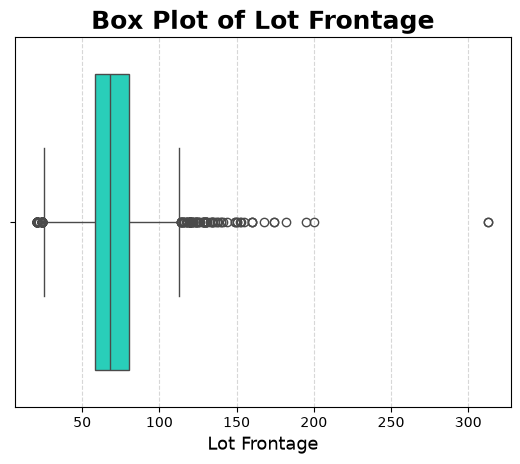

In [24]:
sns.boxplot(data=df, x='Lot Frontage', color="#0DEACD")
plt.title("Box Plot of Lot Frontage", fontsize=18, fontweight="bold")
plt.xlabel("Lot Frontage", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [25]:
df[df['Lot Frontage'] > 120]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
16,17,527225035,50,RL,152.0,12134,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,164000
18,19,527276150,20,RL,140.0,19138,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,141000
137,138,535126040,20,RL,137.0,16492,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,190000
234,235,905378040,50,RL,124.0,18600,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,Shed,450,6,2010,WD,Normal,124000
311,312,914476520,20,RL,129.0,9196,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,201000
368,369,527258020,20,RL,124.0,16158,Pave,NaN,IR1,Low,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,260000
435,436,528116010,20,RL,129.0,16870,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,296000
460,461,528186010,20,RL,129.0,16770,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,286500
466,467,528221060,60,RL,149.0,12589,Pave,NaN,IR2,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,174000


In [26]:
df['Lot Frontage'].isnull().sum()

np.int64(490)

In [27]:
print(f"The {((df['Lot Frontage'].isnull().sum()/len(df))*100).round(2)} data is missing")

The 16.72 data is missing


## Univariate Analysis of `Lot Area`

`Lot Area` is a **continuous numerical variable** that represents the total size of the property lot in **square feet**.

### Descriptive Statistics

| Statistic | Lot Area |
|---|---:|
| Count | 2,930 |
| Mean | 10,147.92 sq ft |
| Standard Deviation | 7,880.02 sq ft |
| Minimum | 1,300 sq ft |
| 25th Percentile (Q1) | 7,440.25 sq ft |
| Median (Q2) | 9,436.50 sq ft |
| 75th Percentile (Q3) | 11,555.25 sq ft |
| Maximum | 215,245 sq ft |

### Missing Values

`Lot Area` contains **2,930 non-missing observations**, which is equal to the total number of rows in the dataset.

Therefore, there are **no missing values** in this feature.

### Distribution Analysis

The histogram and KDE plot show that `Lot Area` has a **strongly positively (right) skewed distribution**.

Most properties are concentrated in the lower range of lot sizes, while a relatively small number of properties have extremely large lots.

The long right tail extends beyond **200,000 square feet**, showing the presence of some unusually large properties.

The mean lot area is approximately **10,147.92 sq ft**, while the median is **9,436.50 sq ft**.

Since:

**Mean > Median**

this supports the observation that the distribution is positively skewed.

The extreme values on the right side pull the mean upward.

### Central Tendency

The median lot area is approximately **9,436.50 sq ft**, meaning that half of the properties have lot areas below this value and half have lot areas above it.

The mean is approximately **10,147.92 sq ft**.

Because the distribution contains extreme values and is right-skewed, the **median is a more robust representation of a typical lot size** than the mean.

### Spread

The standard deviation is approximately **7,880.02 sq ft**, which is relatively large compared with the mean.

This indicates substantial variation in property lot sizes.

The middle 50% of observations lie between:

- Q1 = 7,440.25 sq ft
- Q3 = 11,555.25 sq ft

Therefore:

**IQR = Q3 - Q1**

**IQR = 11,555.25 - 7,440.25**

**IQR = 4,115 sq ft**

Thus, the middle 50% of properties have lot sizes within a range of approximately **4,115 sq ft**.

### Outlier Analysis

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 7,440.25 - 1.5(4,115)**

**Lower Bound = 1,267.75 sq ft**

And:

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 11,555.25 + 1.5(4,115)**

**Upper Bound = 17,727.75 sq ft**

Therefore, according to the IQR rule:

- Values below approximately **1,267.75 sq ft** would be potential lower outliers.
- Values above approximately **17,727.75 sq ft** are potential upper outliers.

The minimum observed value is **1,300 sq ft**, which is slightly above the calculated lower bound. Therefore, there are effectively **no lower outliers according to the IQR rule**.

However, the box plot shows a large number of upper outliers above approximately **17,728 sq ft**.

Some particularly extreme observations have lot areas around:

- 100,000+ sq ft
- 150,000+ sq ft
- 200,000+ sq ft

The maximum lot area is **215,245 sq ft**, which is extremely large compared with the median of only **9,436.50 sq ft**.

These observations should **not be removed automatically**. Large lots may represent genuine properties and should first be investigated using other features.

### Range

The minimum lot area is **1,300 sq ft**, while the maximum is **215,245 sq ft**.

Therefore:

**Range = Maximum - Minimum**

**Range = 215,245 - 1,300**

**Range = 213,945 sq ft**

This extremely large range is mainly caused by a small number of properties with exceptionally large lots.

### Key Observations

1. `Lot Area` is a continuous numerical variable measured in square feet.
2. It contains 2,930 observations with no missing values.
3. The median lot area is approximately 9,436.50 sq ft.
4. The mean lot area is approximately 10,147.92 sq ft.
5. The distribution is strongly positively/right skewed.
6. Most properties have much smaller lot areas compared with the extreme observations.
7. The IQR is approximately 4,115 sq ft.
8. Values above approximately 17,727.75 sq ft are potential upper outliers according to the IQR rule.
9. The box plot shows numerous upper outliers.
10. The maximum value of 215,245 sq ft is extremely large compared with the median.
11. There are no lower outliers according to the calculated IQR boundary.
12. Extreme values should be investigated rather than automatically removed.
13. A transformation such as a logarithmic transformation may later be worth investigating because of the strong right skew.

### Conclusion

`Lot Area` has a **strongly right-skewed distribution with numerous high-value outliers**. Most properties have lot sizes concentrated around the lower end of the overall range, while a small number of properties have exceptionally large lots.

There are **no missing values**, so missing-value imputation is not required for this feature.

The strong skewness and extreme upper values may influence regression models. During preprocessing, transformations such as a log transformation and appropriate outlier treatment can be investigated. However, the outliers should not be removed solely because they fall outside the IQR boundaries, as they may represent legitimate large properties.

In [28]:
df['Lot Area']

0       31770
1       11622
2       14267
3       11160
4       13830
        ...  
2925     7937
2926     8885
2927    10441
2928    10010
2929     9627
Name: Lot Area, Length: 2930, dtype: int64

In [29]:
df['Lot Area'].describe()

count      2930.000000
mean      10147.921843
std        7880.017759
min        1300.000000
25%        7440.250000
50%        9436.500000
75%       11555.250000
max      215245.000000
Name: Lot Area, dtype: float64

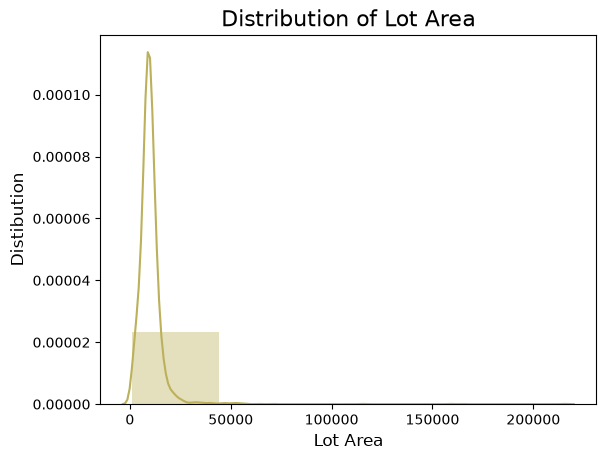

In [30]:
sns.distplot(
    df['Lot Area'],
    bins=5,
    color="#BCB05A"
)
plt.title("Distribution of Lot Area", fontsize=16)
plt.xlabel("Lot Area", fontsize=12)
plt.ylabel("Distibution", fontsize=12)
plt.show()

In [31]:
print(df['Lot Area'].skew())

12.820898171092681


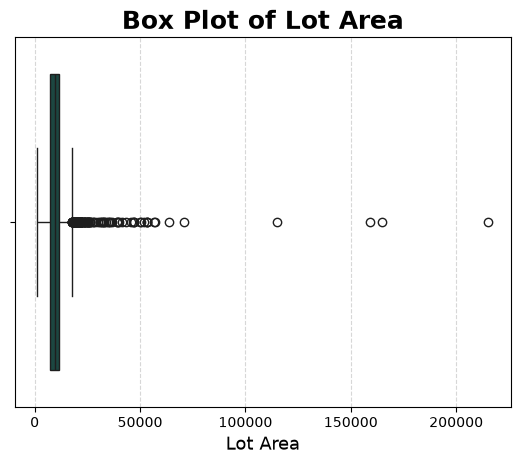

In [32]:
sns.boxplot(data=df, x='Lot Area', color="#154E46")
plt.title("Box Plot of Lot Area", fontsize=18, fontweight="bold")
plt.xlabel("Lot Area", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [33]:
df['Lot Area'].isnull().sum()

np.int64(0)

## Univariate Analysis of `Overall Qual`

`Overall Qual` represents the **overall quality of the material and finish of a house**. It is measured on an ordered scale from **1 to 10**, where higher values indicate better overall quality.

Although the column is stored numerically, it should be understood as an **ordinal variable** because the values represent ordered quality levels.

### Descriptive Statistics

| Statistic | Overall Qual |
|---|---:|
| Count | 2,930 |
| Mean | 6.09 |
| Standard Deviation | 1.41 |
| Minimum | 1 |
| 25th Percentile (Q1) | 5 |
| Median (Q2) | 6 |
| 75th Percentile (Q3) | 7 |
| Maximum | 10 |

### Missing Values

There are **2,930 non-missing observations**, equal to the total number of rows in the dataset.

Therefore, `Overall Qual` contains **no missing values**.

### Distribution Analysis

The distribution shows that most houses have an overall quality rating between approximately **5 and 7**.

The highest concentration occurs around ratings **5, 6, and 7**, indicating that most properties in the dataset have average to above-average overall material and finish quality.

Very low quality ratings such as **1 and 2** are uncommon, while very high ratings such as **9 and 10** are also less frequent.

Since `Overall Qual` contains only integer ratings from 1 to 10, the multiple peaks visible in the KDE curve are partly a consequence of applying KDE to a **discrete ordinal variable**. A count plot would provide an even clearer representation of the frequency of each quality rating.

### Central Tendency

The mean quality rating is approximately **6.09**, while the median is **6**.

Since the mean and median are very close, the center of the distribution is around a quality rating of **6**.

The middle 50% of houses have quality ratings between:

- Q1 = 5
- Median = 6
- Q3 = 7

This indicates that the majority of houses have moderate overall quality.

### Spread

The standard deviation is approximately **1.41**, meaning that quality ratings generally do not vary extremely far from the mean.

The Interquartile Range is:

**IQR = Q3 - Q1**

**IQR = 7 - 5 = 2**

Therefore, the middle 50% of properties fall within a relatively narrow range of **2 quality points**.

### Outlier Analysis

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 5 - 1.5(2) = 2**

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 7 + 1.5(2) = 10**

Therefore, according to the standard IQR rule:

- Values below **2** are potential lower outliers.
- Values above **10** would be potential upper outliers.

Since the maximum possible observed value is 10, there are no upper outliers.

The box plot identifies houses with an `Overall Qual` rating of **1** as lower outliers.

However, these values should **not be treated as errors or automatically removed**. A rating of 1 is a valid value on the defined 1–10 quality scale and simply represents houses with very poor overall quality.

### Important Variable-Type Observation

`Overall Qual` is different from continuous numerical variables such as `Lot Area` and `Lot Frontage`.

For example:

- `Lot Area` → continuous numerical variable
- `Overall Qual` → discrete **ordinal** variable

The values have a meaningful order:

**1 < 2 < 3 < ... < 9 < 10**

Therefore, preserving this ordering is important during analysis and modeling.

### Key Observations

1. `Overall Qual` is a discrete ordinal variable ranging from 1 to 10.
2. It contains 2,930 observations with no missing values.
3. The average quality rating is approximately 6.09.
4. The median quality rating is 6.
5. Most houses have quality ratings between 5 and 7.
6. The middle 50% of observations lie between ratings 5 and 7.
7. The IQR is 2.
8. Rating 1 appears as a statistical outlier according to the IQR method.
9. Rating 1 is still a valid value and should not automatically be removed.
10. There are no values outside the valid 1–10 rating range.
11. Because this is an ordinal/discrete feature, a count plot can be more informative than a histogram with KDE.

### Conclusion

`Overall Qual` is an **ordinal quality-rating feature** with values ranging from 1 to 10. Most properties are concentrated around ratings **5–7**, with a median rating of **6**.

The feature contains **no missing values**. Although rating 1 is identified as an outlier by the IQR method, it represents a valid quality level rather than necessarily being an erroneous observation.

Because the variable represents ordered quality levels rather than a truly continuous measurement, its ordinal nature should be preserved during preprocessing and modeling.

In [34]:
df['Overall Qual']

0       6
1       5
2       6
3       7
4       5
       ..
2925    6
2926    5
2927    5
2928    5
2929    7
Name: Overall Qual, Length: 2930, dtype: int64

In [35]:
df['Overall Qual'].describe()

count    2930.000000
mean        6.094881
std         1.411026
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: Overall Qual, dtype: float64

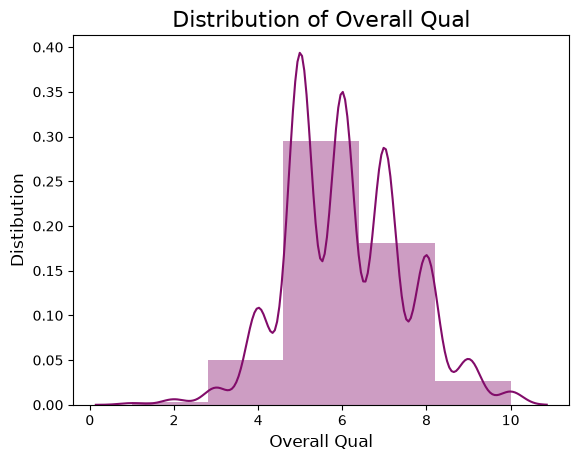

In [36]:
sns.distplot(
    df['Overall Qual'],
    bins=5,
    color="#820C6A"
)
plt.title("Distribution of Overall Qual", fontsize=16)
plt.xlabel("Overall Qual", fontsize=12)
plt.ylabel("Distibution", fontsize=12)
plt.show()

In [37]:
print(df['Overall Qual'].skew())

0.19063395602395453


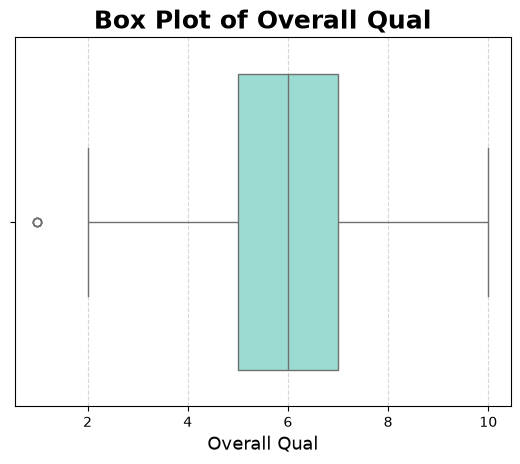

In [38]:
sns.boxplot(data=df, x='Overall Qual', color="#91E5DA")
plt.title("Box Plot of Overall Qual", fontsize=18, fontweight="bold")
plt.xlabel("Overall Qual", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [39]:
df['Overall Qual'].isnull().sum()

np.int64(0)

## Univariate Analysis of `Overall Cond`

`Overall Cond` represents the **overall condition of a house**. It is an **ordinal variable**, where higher values indicate that the property is in better overall condition.

It should not be confused with `Overall Qual`:

- `Overall Qual` → overall material and finish **quality**
- `Overall Cond` → overall **current condition** of the property

### Descriptive Statistics

| Statistic | Overall Cond |
|---|---:|
| Count | 2,930 |
| Mean | 5.56 |
| Standard Deviation | 1.11 |
| Minimum | 1 |
| 25th Percentile (Q1) | 5 |
| Median (Q2) | 5 |
| 75th Percentile (Q3) | 6 |
| Maximum | 9 |

### Missing Values

`Overall Cond` contains **2,930 non-missing observations**, equal to the total number of rows in the dataset.

Therefore, there are **no missing values** in this feature.

### Distribution Analysis

The distribution shows a very strong concentration around a condition rating of **5**.

Most houses have condition ratings between approximately **5 and 7**, while ratings at the extreme ends of the scale are relatively uncommon.

The mean condition rating is approximately **5.56**, while the median is **5**.

The distribution is not continuous because `Overall Cond` represents discrete ordered ratings. Therefore, the individual peaks visible in the KDE curve correspond to different rating levels rather than a truly continuous distribution.

A **count plot** would therefore be more appropriate for understanding the frequency of each rating.

### Central Tendency

The mean condition rating is approximately **5.56**, while the median is **5**.

The 25th percentile is also 5, which indicates that a large proportion of properties are concentrated around this rating.

The typical property in the dataset therefore has an overall condition around **5–6**.

### Spread

The standard deviation is approximately **1.11**, showing that most condition ratings remain relatively close to the center of the distribution.

The middle 50% of observations lie between:

- Q1 = 5
- Median = 5
- Q3 = 6

The Interquartile Range is:

**IQR = Q3 - Q1**

**IQR = 6 - 5 = 1**

Therefore, the middle 50% of houses fall within only **one condition-rating point**, indicating a highly concentrated distribution.

### Outlier Analysis

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 5 - 1.5(1) = 3.5**

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 6 + 1.5(1) = 7.5**

Therefore, according to the IQR rule:

- Ratings below **3.5** are identified as potential lower outliers.
- Ratings above **7.5** are identified as potential upper outliers.

This means ratings:

- **1, 2 and 3** may appear as lower outliers.
- **8 and 9** may appear as upper outliers.

The box plot clearly shows these observations on both sides.

However, these should **not be automatically removed**.

`Overall Cond` is an ordinal rating variable, and values such as 1, 2, 3, 8 and 9 are legitimate values representing properties with unusually poor or unusually good condition.

In this case, the IQR method identifies **rare ratings**, not necessarily incorrect observations.

### Important Interpretation of the Box Plot

For a continuous feature such as `Lot Area`, extreme IQR values may deserve investigation as potential numerical outliers.

For `Overall Cond`, the situation is different.

The variable has a limited ordered rating scale:

**1 < 2 < 3 < ... < 9**

Therefore, a rating of 9 cannot be considered invalid simply because the box plot labels it as an outlier.

The box plot mainly tells us that **extreme condition ratings occur much less frequently than ratings around 5–6**.

### Key Observations

1. `Overall Cond` is a discrete ordinal variable.
2. It contains 2,930 observations with no missing values.
3. The mean condition rating is approximately 5.56.
4. The median condition rating is 5.
5. Most houses are concentrated around ratings 5 and 6.
6. The IQR is only 1, showing a highly concentrated middle 50% of observations.
7. Ratings below 3.5 and above 7.5 are classified as statistical outliers by the IQR method.
8. Ratings 1–3 and 8–9 are rare compared with the central ratings.
9. These extreme ratings are valid values and should not automatically be removed.
10. A count plot is more suitable than KDE for examining the exact distribution of this ordinal feature.

### Conclusion

`Overall Cond` is an **ordinal feature with a strongly concentrated distribution around ratings 5–6**. The median condition rating is 5, while the mean is approximately 5.56.

The feature contains **no missing values**. The box plot identifies low ratings (1–3) and high ratings (8–9) as statistical outliers, but these represent valid condition levels rather than necessarily erroneous observations.

Therefore, these values should generally be preserved unless later analysis provides a specific reason to treat them differently.

In [40]:
df['Overall Cond']

0       5
1       6
2       6
3       5
4       5
       ..
2925    6
2926    5
2927    5
2928    5
2929    5
Name: Overall Cond, Length: 2930, dtype: int64

In [41]:
df['Overall Cond'].describe()

count    2930.000000
mean        5.563140
std         1.111537
min         1.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         9.000000
Name: Overall Cond, dtype: float64

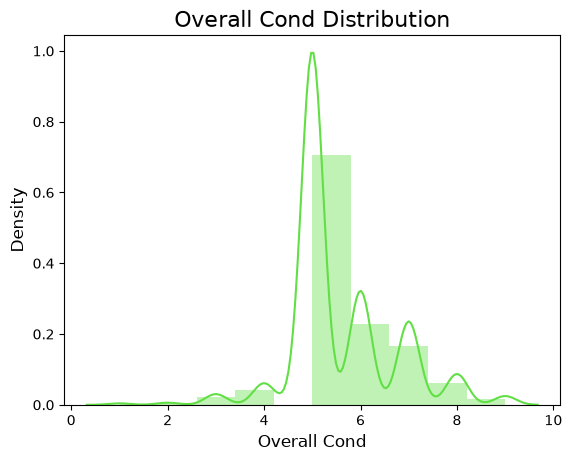

In [42]:
sns.distplot(
    df['Overall Cond'],
    bins=10,
    color="#61DF44",            
)
plt.title("Overall Cond Distribution", fontsize=16)
plt.xlabel("Overall Cond", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

In [43]:
print(df['Overall Cond'].skew())

0.5744294770321869


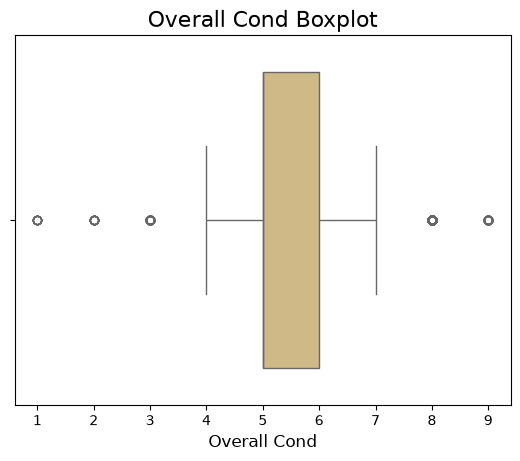

In [44]:
sns.boxplot(data=df, x='Overall Cond', color="#DBBD7B")
plt.title("Overall Cond Boxplot", fontsize=16)
plt.xlabel("Overall Cond", fontsize=12)
plt.show()

In [45]:
df['Overall Cond'].isnull().sum()

np.int64(0)

## Univariate Analysis of `Year Built`

`Year Built` represents the **original construction year of the house**. It is a numerical temporal feature and provides information about the age of a property.

### Descriptive Statistics

| Statistic | Year Built |
|---|---:|
| Count | 2,930 |
| Mean | 1971.36 |
| Standard Deviation | 30.25 years |
| Minimum | 1872 |
| 25th Percentile (Q1) | 1954 |
| Median (Q2) | 1973 |
| 75th Percentile (Q3) | 2001 |
| Maximum | 2010 |

### Missing Values

`Year Built` contains **2,930 non-missing observations**, equal to the total number of rows in the dataset.

Therefore, there are **no missing values** in this feature.

### Distribution Analysis

The distribution of `Year Built` is **not normally distributed**.

The histogram shows that:

- A relatively small number of houses were built before 1900.
- The number of houses generally increases for more recent construction periods.
- A large concentration of properties was built between approximately **1950 and 2010**.
- There is a particularly strong concentration of houses built around the late 1990s and 2000s.
- The distribution has a longer tail toward older construction years.

The mean construction year is approximately **1971**, while the median is **1973**. Their relatively close values indicate that the central construction period is around the early 1970s, although the overall distribution is irregular and contains multiple concentrations across different periods.

### Age Range of Properties

The oldest house in the dataset was built in **1872**, while the newest was built in **2010**.

Therefore:

**Construction Year Range = 2010 - 1872 = 138 years**

The dataset consequently contains houses from a very wide range of construction periods.

### Quartile Analysis

The quartiles show:

- 25% of houses were built in or before **1954**.
- 50% of houses were built in or before **1973**.
- 75% of houses were built in or before **2001**.
- The newest 25% of houses were built between approximately **2001 and 2010**.

The middle 50% of properties were therefore constructed between **1954 and 2001**.

### IQR Analysis

The Interquartile Range is:

**IQR = Q3 - Q1**

**IQR = 2001 - 1954 = 47 years**

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 1954 - 1.5(47)**

**Lower Bound = 1883.5**

And:

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 2001 + 1.5(47)**

**Upper Bound = 2071.5**

According to the standard IQR rule, houses built before approximately **1883.5** are identified as potential statistical outliers.

The box plot confirms that a small number of very old houses appear as lower outliers.

### Important Note About Outliers

The old construction years should **not automatically be removed as outliers**.

For example, a house built in 1872 may simply represent a genuine historic property rather than incorrect data.

Unlike variables such as `Lot Area`, applying traditional outlier removal directly to `Year Built` can be misleading because construction year has a real historical meaning.

Therefore, these old properties should be retained unless further analysis provides evidence that they are erroneous observations.

### Feature Engineering Potential

`Year Built` is especially useful for feature engineering.

The raw year itself may be less informative than the **age of the house when it was sold**.

A potential derived feature is:

**House Age = Yr Sold - Year Built**

For example, if a house was built in 1980 and sold in 2010:

**House Age = 2010 - 1980 = 30 years**

This could provide a more meaningful representation of property age for a house-price prediction model.

This feature should be considered later during the feature-engineering stage rather than created solely as part of univariate analysis.

### Key Observations

1. `Year Built` is a numerical temporal feature representing the original construction year.
2. It contains 2,930 observations with no missing values.
3. Houses were built between 1872 and 2010.
4. The median construction year is 1973.
5. The mean construction year is approximately 1971.
6. The middle 50% of houses were built between 1954 and 2001.
7. The construction years span approximately 138 years.
8. The distribution is not normal and contains concentrations from different construction periods.
9. More properties are concentrated in relatively recent construction periods.
10. A small number of very old houses appear as statistical outliers in the box plot.
11. These old houses should not automatically be removed because they may represent legitimate historical properties.
12. `Year Built` has strong feature-engineering potential through the creation of a `House Age` variable.

### Conclusion

`Year Built` shows that the Ames Housing dataset contains properties from a **wide range of construction periods**, ranging from 1872 to 2010. Most properties are concentrated in the second half of the twentieth century and the early 2000s, while only a small number were constructed before 1900.

Although some very old houses are identified as statistical outliers by the IQR method, these observations are likely meaningful rather than erroneous. Therefore, removing them solely based on an outlier rule would not be appropriate.

For future modeling, converting the construction year into a property-age feature using `Yr Sold - Year Built` may provide a more interpretable predictor of house prices.

In [46]:
df['Year Built']

0       1960
1       1961
2       1958
3       1968
4       1997
        ... 
2925    1984
2926    1983
2927    1992
2928    1974
2929    1993
Name: Year Built, Length: 2930, dtype: int64

In [47]:
df['Year Built'].describe()

count    2930.000000
mean     1971.356314
std        30.245361
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2001.000000
max      2010.000000
Name: Year Built, dtype: float64

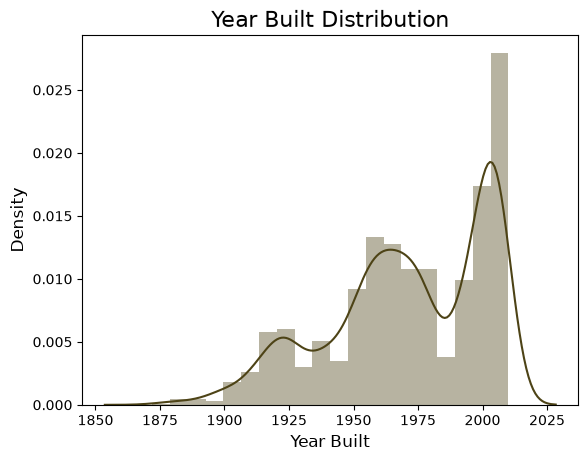

In [48]:
sns.distplot(
    df['Year Built'],
    bins=20,
    color="#4D4316",         
)
plt.title("Year Built Distribution", fontsize=16)
plt.xlabel("Year Built", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

In [49]:
print(df['Year Built'].skew())

-0.6044622213681587


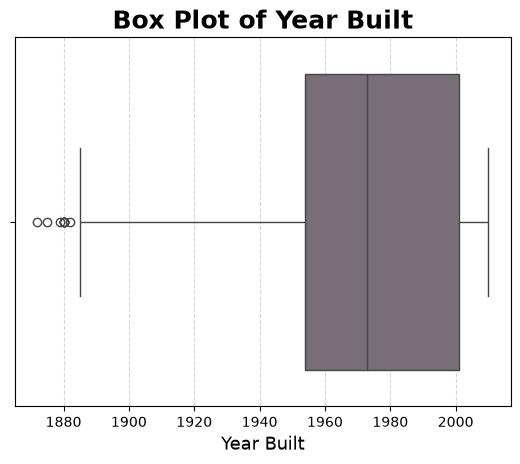

In [50]:
sns.boxplot(data=df, x='Year Built', color="#786D78")
plt.title("Box Plot of Year Built", fontsize=18, fontweight="bold")
plt.xlabel("Year Built", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

## Univariate Analysis of `Year Remod/Add`

`Year Remod/Add` represents the **year in which a house was remodeled or had an addition made**. If a property was never remodeled, the value generally corresponds to its original construction year.

It is a **numerical temporal variable**.

### Descriptive Statistics

| Statistic | Year Remod/Add |
|---|---:|
| Count | 2,930 |
| Mean | 1984.27 |
| Standard Deviation | 20.86 years |
| Minimum | 1950 |
| 25th Percentile (Q1) | 1965 |
| Median (Q2) | 1993 |
| 75th Percentile (Q3) | 2004 |
| Maximum | 2010 |

### Missing Values

`Year Remod/Add` contains **2,930 non-missing observations**, which is equal to the total number of rows in the dataset.

Therefore, this feature contains **no missing values**.

### Distribution Analysis

The histogram and KDE plot show that `Year Remod/Add` does **not follow a normal distribution**.

The distribution has noticeable concentrations around different periods.

A particularly large concentration occurs around **1950**. This is important because the dataset records remodeling years starting from 1950, and older properties that were not remodeled can therefore contribute to this concentration.

Another major concentration occurs during the **late 1990s and 2000s**, showing that many properties were either remodeled, updated, or originally constructed during relatively recent years.

The distribution can therefore be described as **irregular/multimodal rather than normally distributed**.

### Central Tendency

The mean remodeling year is approximately **1984**, while the median is **1993**.

Since:

**Mean < Median**

older remodeling years pull the mean downward.

The median indicates that approximately half of the properties have a `Year Remod/Add` value of **1993 or earlier**, while the other half have values of **1993 or later**.

### Quartile Analysis

The quartiles are:

- Q1 = 1965
- Median = 1993
- Q3 = 2004

This means that the middle 50% of observations fall between **1965 and 2004**.

It also shows that approximately 25% of properties have remodeling/addition years from **2004 onward**.

### Spread

The standard deviation is approximately **20.86 years**, indicating substantial variation in remodeling periods across the properties.

The Interquartile Range is:

**IQR = Q3 - Q1**

**IQR = 2004 - 1965**

**IQR = 39 years**

Therefore, the middle 50% of observations span approximately **39 years**.

### Outlier Analysis

Using the IQR method:

**Lower Bound = Q1 - 1.5 × IQR**

**Lower Bound = 1965 - 1.5(39)**

**Lower Bound = 1906.5**

And:

**Upper Bound = Q3 + 1.5 × IQR**

**Upper Bound = 2004 + 1.5(39)**

**Upper Bound = 2062.5**

The observed values range from **1950 to 2010**, meaning that all observations fall inside these IQR boundaries.

Therefore, the box plot shows **no statistical outliers** for `Year Remod/Add` according to the 1.5 × IQR rule.

### Range

The minimum value is **1950**, while the maximum value is **2010**.

Therefore:

**Range = 2010 - 1950**

**Range = 60 years**

The feature covers approximately six decades of remodeling/addition information.

### Important Interpretation

`Year Remod/Add` should not be interpreted exactly like an ordinary continuous numerical feature.

A difference such as:

**2010 - 1980 = 30 years**

has meaningful temporal information.

The raw year may therefore be useful, but derived features could potentially provide more meaningful information for predicting house prices.

For example:

**Years Since Remodel = Yr Sold - Year Remod/Add**

A smaller value would indicate that the property was remodeled relatively recently when it was sold.

Another potentially useful feature could describe whether a house was remodeled after its original construction:

**Was Remodeled = Year Remod/Add > Year Built**

These transformations can be investigated later during feature engineering.

### Key Observations

1. `Year Remod/Add` is a numerical temporal variable.
2. It contains 2,930 observations.
3. There are no missing values.
4. Values range from 1950 to 2010.
5. The mean remodeling/addition year is approximately 1984.
6. The median is 1993.
7. The middle 50% of observations fall between 1965 and 2004.
8. The IQR is 39 years.
9. The distribution is not normal and shows multiple concentrations.
10. There is a noticeable concentration around 1950.
11. Another strong concentration appears around the late 1990s and 2000s.
12. No observations are classified as outliers using the standard IQR rule.
13. The feature has strong potential for feature engineering, particularly `Years Since Remodel`.

### Conclusion

`Year Remod/Add` contains **no missing values or IQR-based outliers**, but its distribution is clearly non-normal and shows concentrations across different remodeling periods.

Many observations are concentrated in relatively recent years, particularly around the 2000s, while another noticeable group occurs around 1950.

Rather than treating this variable like an ordinary continuous measurement, its **temporal meaning should be preserved**. During feature engineering, variables such as `Years Since Remodel` and whether the property was actually remodeled may provide more useful information for predicting `SalePrice`.

In [51]:
df['Year Remod/Add']

0       1960
1       1961
2       1958
3       1968
4       1998
        ... 
2925    1984
2926    1983
2927    1992
2928    1975
2929    1994
Name: Year Remod/Add, Length: 2930, dtype: int64

In [52]:
df['Year Remod/Add'].describe()

count    2930.000000
mean     1984.266553
std        20.860286
min      1950.000000
25%      1965.000000
50%      1993.000000
75%      2004.000000
max      2010.000000
Name: Year Remod/Add, dtype: float64

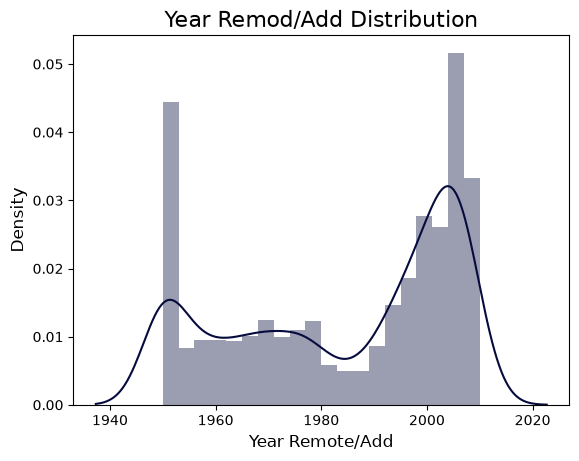

In [53]:
sns.distplot(
    df['Year Remod/Add'],
    bins=20,
    color="#060B3E",          
)
plt.title("Year Remod/Add Distribution", fontsize=16)
plt.xlabel("Year Remote/Add", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

In [54]:
print(df['Year Remod/Add'].skew())

-0.4518626526946543


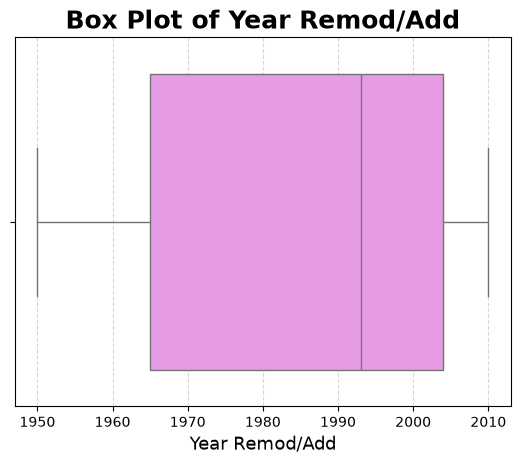

In [55]:
sns.boxplot(data=df, x='Year Remod/Add', color="#F38FF1")
plt.title("Box Plot of Year Remod/Add", fontsize=18, fontweight="bold")
plt.xlabel("Year Remod/Add", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [56]:
df['Year Remod/Add'].isnull().sum()

np.int64(0)